In [1]:
# Task 1

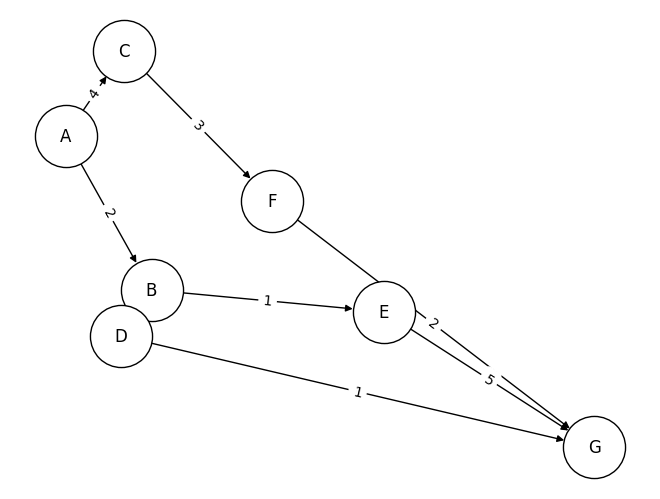

Admissibility Check:
Node A: h(n)=7, Actual=8 : True
Node B: h(n)=6, Actual=6 : True
Node C: h(n)=4, Actual=5 : True
Node D: h(n)=1, Actual=1 : True
Node E: h(n)=2, Actual=5 : True
Node F: h(n)=2, Actual=2 : True
Node G: h(n)=0, Actual=0 : True
Overall Admissible: True

Consistency Check:
A to B: 7 <= 2 + 6 : True
A to C: 7 <= 4 + 4 : True
B to D: 6 <= 7 + 1 : True
B to E: 6 <= 1 + 2 : False
C to F: 4 <= 3 + 2 : True
D to G: 1 <= 1 + 0 : True
E to G: 2 <= 5 + 0 : True
F to G: 2 <= 2 + 0 : True
Overall Consistent: False


In [23]:
import networkx as nx
import matplotlib.pyplot as plt

abstract_graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

actual_costs_to_G = {
    'A': 8,
    'B': 6,
    'C': 5,
    'D': 1,
    'E': 5,
    'F': 2,
    'G': 0
}


def visualize():
    G = nx.DiGraph()

    for node in abstract_graph:
        for neighbor, cost in abstract_graph[node].items():
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G, seed=42) # Added seed for consistent layout
    nx.draw(G, pos, with_labels=True, node_color='white', edgecolors='black', node_size=2000)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    
    plt.show()


def h(n):
    return heuristic_table[n]

def task_1_evaluation():
    print("Admissibility Check:")
    is_admissible = True
    for node in abstract_graph:
        admissible = h(node) <= actual_costs_to_G[node]
        if not admissible:
            is_admissible = False
        print(f"Node {node}: h(n)={h(node)}, Actual={actual_costs_to_G[node]} : {admissible}")
        
    print(f"Overall Admissible: {is_admissible}\n")
    
    print("Consistency Check:")
    is_consistent = True
    for node, edges in abstract_graph.items():
        for neighbor, cost in edges.items():
            consistent = h(node) <= cost + h(neighbor)
            if not consistent:
                is_consistent = False
            print(f"{node} to {neighbor}: {h(node)} <= {cost} + {h(neighbor)} : {consistent}")
            
    print(f"Overall Consistent: {is_consistent}")

if __name__ == "__main__":
    visualize()
    task_1_evaluation()

In [4]:
# Task 2

In [11]:
import heapq

abstract_graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'D': 7, 'E': 1},
    'C': {'F': 3},
    'D': {'G': 1},
    'E': {'G': 5},
    'F': {'G': 2},
    'G': {}
}

heuristic_table = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 1,
    'E': 2,
    'F': 2,
    'G': 0
}

def get_neighbors(graph, current_node):
    return list(graph[current_node].keys())

def get_neighbors_with_costs(graph, current_node):
    return graph[current_node].items()

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from.get(current)
    path.reverse()
    return path




def greedy_best_first_search(start, goal, graph, h_values):
    frontier = []
    heapq.heappush(frontier, (h_values[start], start))
    explored = [] 
    came_from = {start: None}
    
    while frontier:
        current_h, current_node = heapq.heappop(frontier)
        
        if current_node not in explored:
            explored.append(current_node)
            
        if current_node == goal:
            path = reconstruct_path(came_from, current_node)
            cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
            return path, explored, cost
            
        for neighbor in get_neighbors(graph, current_node):
            in_frontier = any(neighbor == item[1] for item in frontier)
            if neighbor not in explored and not in_frontier:
                heapq.heappush(frontier, (h_values[neighbor], neighbor))
                came_from[neighbor] = current_node
                
    return None, explored, 0

gbfs_path, gbfs_expansions, gbfs_cost = greedy_best_first_search('A', 'G', abstract_graph, heuristic_table)
print(f"GBFS expansions: {gbfs_expansions}")
print(f"GBFS path: {gbfs_path}")
print(f"GBFS cost: {gbfs_cost}")

GBFS Expansions: ['A', 'C', 'F', 'G']
GBFS Path: ['A', 'C', 'F', 'G']
GBFS Cost: 9


In [6]:
# Task 3

In [28]:
def a_star_search(start, goal, graph, h_values):
    frontier = []
    heapq.heappush(frontier, (h_values[start], start))
    came_from = {start: None}
    g_costs = {start: 0}
    explored = []
    
    while frontier:
        current_f, current_node = heapq.heappop(frontier)
        
        if current_node not in explored:
            explored.append(current_node)
            
        if current_node == goal:
            return reconstruct_path(came_from, current_node), g_costs[current_node], explored
            
        for neighbor, step_cost in get_neighbors_with_costs(graph, current_node):
            tentative_g = g_costs[current_node] + step_cost
            if neighbor not in g_costs or tentative_g < g_costs[neighbor]:
                g_costs[neighbor] = tentative_g
                f_score = tentative_g + h_values[neighbor]
                heapq.heappush(frontier, (f_score, neighbor))
                came_from[neighbor] = current_node
                
    return None, 0, explored

astar_path, astar_cost, astar_expansions = a_star_search('A', 'G', abstract_graph, heuristic_table)
print(f"A* expansions: {astar_expansions}")
print(f"A* path: {astar_path}")
print(f"A* cost: {astar_cost}")

A* expansions: ['A', 'B', 'E', 'C', 'G']
A* path: ['A', 'B', 'E', 'G']
A* cost: 8


In [8]:
# Task 4

In [30]:
def weighted_a_star(start, goal, graph, h_values, w):
    frontier = []
    heapq.heappush(frontier, (h_values[start] * w, start)) 
    came_from = {start: None}
    g_costs = {start: 0}
    nodes_expanded = 0
    
    while frontier:
        current_f, current_node = heapq.heappop(frontier)
        nodes_expanded += 1
            
        if current_node == goal:
            return reconstruct_path(came_from, current_node), g_costs[current_node], nodes_expanded
            
        for neighbor, step_cost in get_neighbors_with_costs(graph, current_node):
            tentative_g = g_costs[current_node] + step_cost
            if neighbor not in g_costs or tentative_g < g_costs[neighbor]:
                g_costs[neighbor] = tentative_g
                f_score = tentative_g + (w * h_values[neighbor]) 
                heapq.heappush(frontier, (f_score, neighbor))
                came_from[neighbor] = current_node
                
    return None, 0, nodes_expanded

for w in [1.0, 1.5, 2.0]:
    path, cost, expansions = weighted_a_star('A', 'G', abstract_graph, heuristic_table, w)
    print(f"w={w} ; path: {path} ; cost: {cost} ; expansions: {expansions}")

w=1.0 ; path: ['A', 'B', 'E', 'G'] ; cost: 8 ; expansions: 5
w=1.5 ; path: ['A', 'C', 'F', 'G'] ; cost: 9 ; expansions: 4
w=2.0 ; path: ['A', 'C', 'F', 'G'] ; cost: 9 ; expansions: 4
